In [1]:
import numpy as np   #importing necessary libaries
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from matplotlib import gridspec

In [2]:
data = pd.read_csv("D:\machine learning\creditcard.csv") # load data set 

In [3]:
data.head()   # viewing the data 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print(data.shape)  # checking rowXcolumns of data
print(data.describe()) # taking a closer look of data and its 

(284807, 31)
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271

In [5]:
# checking fraud cases in data 
fraud =data[data['Class'] ==1]  # the class lables "1" for minority class here as fraud  transactions 
valid = data[data['Class'] ==0] #the class lables "0" for majority class here as valid  transactions
outlierFraction = len(fraud)/float(len(valid)) # calculating the ratio of fraud transactions to valid transactions
print(outlierFraction) #ratio of fraud compared to valid transactions
print('Fraud Cases :{}'.format(len(data[data['Class'] ==1]))) # number of fraud transactions present in dataset
print('Valid Transactions:{}'.format(len(data[data['Class'] ==0]))) # number of valid transctions presect in dataset

0.0017304750013189597
Fraud Cases :492
Valid Transactions:284315


only 0.17% of transactions are fraud transaction . it's seems the data is highly imbalanced .
1.Lets  apply standard models wiyhout balancing data 

2. if we don't get good accuracy then we can find a way to balance the data 

In [6]:
print("Amount details of the fraudelent transactions")
fraud.Amount.describe()

Amount details of the fraudelent transactions


count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [7]:
print("details od valid transactions")
valid.Amount.describe()

details od valid transactions


count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Compared to the valid transaction in fraudulent transaction average money tranasctions are more.


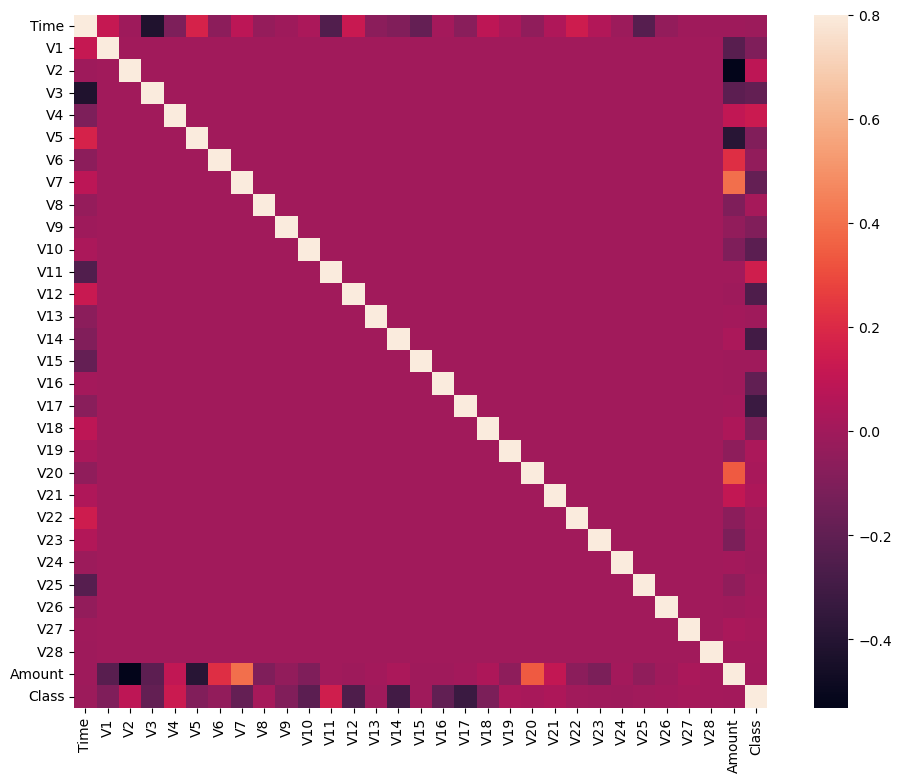

In [8]:
corrmat = data.corr() #plotaing corealation matrix gives us idea of how features are related
fig = plt.figure(figsize =(12, 9))
sns.heatmap(corrmat, vmax =.8, square= True)
plt.show()


in this heatmap we can clearly see not all features are corelated but but some are positively and some are negatively corelated.
Here V2 and V5 are negatively corelated with the feature called Amount .

In [9]:
#deviding data into input parameters and output values
X = data.drop(['Class'], axis =1)
Y = data["Class"]
print(X.shape)
print(Y.shape) 
xData = X.values
yData = Y.values  #it's a numpy array with no columns
                 # taking  just the values for the sake of processing

(284807, 30)
(284807,)


Dividing data into test-train set Using Scikit-learn .

One set for Traning model and Other for testing Our Trained models accuracy.

We are spliting data into 80-20 ration for traning and testing


In [10]:
from sklearn.model_selection import train_test_split
xTrain, xTest, yTrain, yTest =train_test_split(xData, yData, test_size =0.2, random_state =42)
                                                      #spliting data for traning and testing set

In [11]:
#building the Random forest classifier 
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier() #creating random forest model
rfc.fit(xTrain, yTrain)
yPred = rfc.predict(xTest)


In [12]:
#importing nessesary classifier and its modules
from sklearn.metrics import classification_report, accuracy_score  
from sklearn.metrics import precision_score, recall_score 
from sklearn.metrics import f1_score, matthews_corrcoef 
from sklearn.metrics import confusion_matrix 
  
n_outliers = len(fraud) # calculating the fraud cases in dataset
n_errors = (yPred != yTest).sum() # \\calculating misclassifications made by the model.yPred = predicted labels and yTest = true labels. (yPred != yTest) creates a Boolean array, where True indicates a mismatch between the predicted and actual labels, and sum() counts how many such errors occur.\\
print("The model used is Random Forest classifier") 
  
acc = accuracy_score(yTest, yPred) # acc = total correct prediction (both true +ve and -ve) out of all prediction
print("The accuracy is {}".format(acc)) 
  
prec = precision_score(yTest, yPred) # ratio of all true positive to all predicted positive
print("The precision is {}".format(prec)) 
  
rec = recall_score(yTest, yPred) #ratio of true positive to all actual positive
print("The recall is {}".format(rec)) 
  
f1 = f1_score(yTest, yPred) #F1 Score is the harmonic mean of precision and recall
print("The F1-Score is {}".format(f1)) 
  
#Matthews Correlation Coefficient (MCC)
MCC = matthews_corrcoef(yTest, yPred) # it's correlation coefficient between the observed and predicted binary classifications
print("The Matthews correlation coefficient is{}".format(MCC))

The model used is Random Forest classifier
The accuracy is 0.9995786664794073
The precision is 0.9868421052631579
The recall is 0.7653061224489796
The F1-Score is 0.8620689655172413
The Matthews correlation coefficient is0.8688552993136148


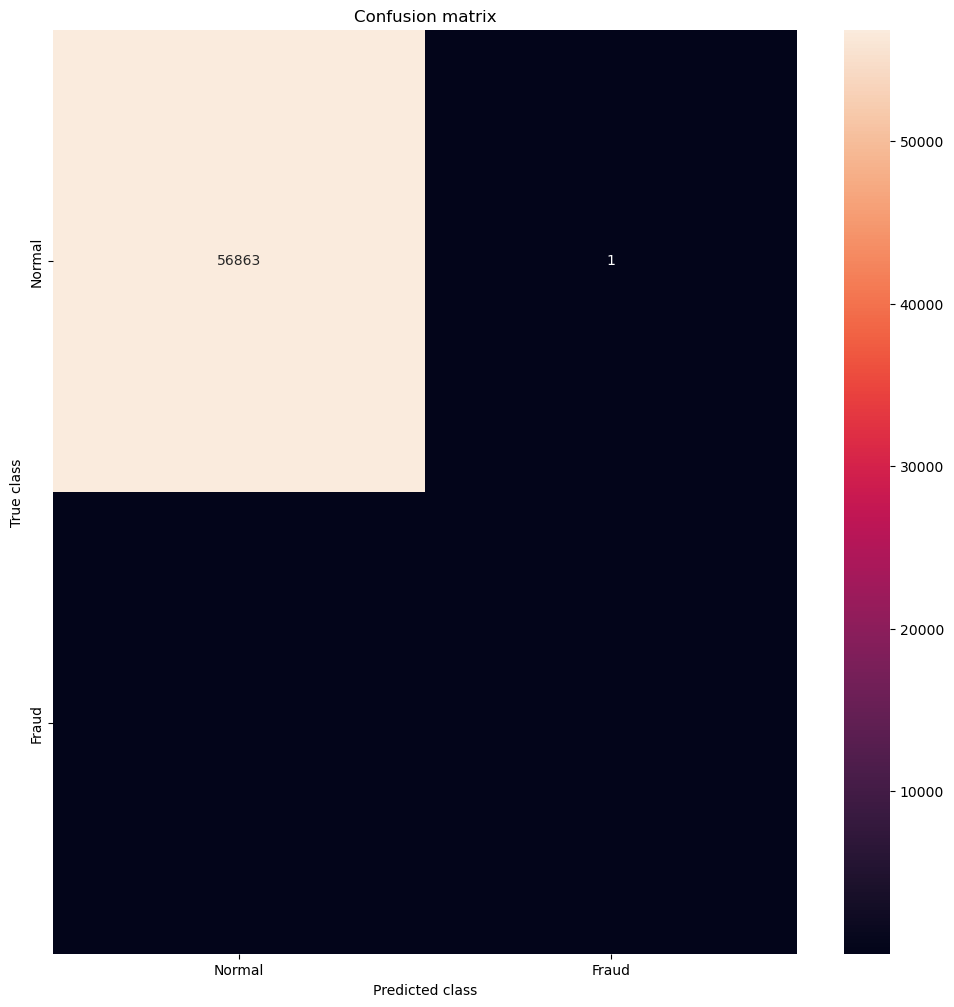

In [13]:
# Visualizion of comfusion matrix
LABELS = ['Normal', 'Fraud'] 
conf_matrix = confusion_matrix(yTest, yPred) 
plt.figure(figsize =(12, 12)) 
sns.heatmap(conf_matrix, xticklabels = LABELS,  
            yticklabels = LABELS, annot = True, fmt ="d"); 
plt.title("Confusion matrix") 
plt.ylabel('True class') 
plt.xlabel('Predicted class') 
plt.show() 

----------------------------------------------------------------REPORT-----------------------------------------------------------------------------= 

                                              
The objective of this project was to creat a Random Forest model capable of deceting fraud in Credit card tranasections to minimize the losses of the business.


In this data mose of the transactions are legitmate only 429 fraud out of 284807 transactions which is only 0.17% of all the transactions, Thus it's a very unbalanced data. We have to build a model which can handling this type of data, in this case Random Forest classifier is one of the best choise



MODEL OVERVIEW

Random forest is a popular choies for camplex classification tasks due to its effectiveness in habdling large imbalanced classes.


Model Performence Overview

1. Accuracy: 0.9996

The model reaches very high accuracy rate, indicates it's correctly classified aproximately 99.96% of the total transactions,suggesting it's effectivness in identifying both fraudulent and legitimate transactions under test conditions.

2. Precision: 0.987

High Precision Score indicates that out of all transactions classified as fraudulent, 98.7% actually were fraudulent. 
High Precision Score is crucial in fraud detection.

3. Recall: 0.765

The Recall score is lower than other metrics is still resonably good ability of the model to detect fraud. recall of 76.5% means it successfully identified 76.5% of all actual fraudulent transactions.

4. F1-score:0.862

F1 score which balances precision and recall, is 0.862, indicating a strong overall performance of the model in terms of precision and recall trade-off.

5. Matthews Correlation Coefficient (MCC): 0.869

The MCC Score is very high at 0.869, suggesting that the model has a strong correlation between the observed and predicted classifications. This score further supports the model's reliability as MCC is considered a balanced measure that can be used even with imbalanced datasets.

------------------------------------------------------------------CONCLUSION----------------------------------------------------------------------------

The Random Forest classifier has demonstrated excellent performance across several key metrics, particularly in accuracy and precision, but the Recall rate suggests that there is some potential for missing fraudlent transactions.
This could be the are 